# **Imaging Esophageal Cancer Status Prediction**

## Dataset Overview
**Name:** Esophageal Endoscopy

This project utilizes the Esophageal Endoscopy dataset consisting of images categorized into two classes:
* **Esophagus (Positive/Abnormal):** Images showing signs of disease or specific esophageal features.
* **No-Esophagus (Negative/Normal):** Images of healthy tissue or other regions.

## Workflow
1.  **Data Ingestion:** Scanning directories and mapping file paths into a structured DataFrame.
2.  **Preprocessing:** * Stratified splitting (Train/Val/Test).
    * Resizing images to 224x224.
    * Creating efficient TensorFlow Datasets.
3.  **Balancing:** Implementing an oversampling pipeline to handle class imbalance.
4.  **Visualization:** Checking target class distribution and inspecting sample images.
5.  **Modeling:** Transfer Learning using **EfficientNetB0** (pretrained on ImageNet).
6.  **Training:** Using Early Stopping and Learning Rate Reduction.
7.  **Evaluation:** Accuracy plots, Classification Reports, and Confusion Matrices.
8.  **Deployment:** Saving the trained model and evaluation reports.

### Cell 01: Library Imports

This cell imports all necessary libraries for file handling (os), data manipulation (pandas, numpy), visualization (seaborn, matplotlib), and deep learning (tensorflow). We also set the random seeds for reproducibility.

In [1]:
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from tqdm.keras import TqdmCallback
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Set Global Visual Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All Libraries have been imported successfully!")

All Libraries have been imported successfully!


### Cell 02: Load and Inspect Data

Loading the image paths and labels from the data directory into a Pandas DataFrame to facilitate inspection and stratified splitting.

In [2]:
# Configuration
IMG_SIZE = 224  # EfficientNet standard input size
BATCH_SIZE = 32
DATA_DIR = r'E:\NLP\Assignment\1&2\Esophageal_Cancer_Project\Data\Imaging\Endoscopy-esophagus'

# 1. Gather all file paths
file_paths = []
labels = []
class_names = sorted(os.listdir(DATA_DIR))

print("Scanning directory...")
for label_idx, class_name in enumerate(class_names):
    class_dir = os.path.join(DATA_DIR, class_name)
    if os.path.isdir(class_dir):
        files = os.listdir(class_dir)
        print(f"Class '{class_name}': found {len(files)} images")
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_paths.append(os.path.join(class_dir, f))
                labels.append(label_idx)

# Create a DataFrame
df = pd.DataFrame({
    'path': file_paths,
    'label': labels,
    'class_name': [class_names[l] for l in labels]
})

print(f"\nDataset Loaded. Total Images: {len(df)}, Total Classes: {len(class_names)}")
print("\nFirst 5 Rows of Dataset Metadata")
display(df.head())

Scanning directory...
Class 'esophagus': found 1689 images
Class 'no-esophagus': found 8973 images

Dataset Loaded. Total Images: 10662, Total Classes: 2

First 5 Rows of Dataset Metadata


,path,label,class_name
0,E:\NLP\Assignment\1&2\Esophageal_Cancer_Projec...,0,esophagus
1,E:\NLP\Assignment\1&2\Esophageal_Cancer_Projec...,0,esophagus
2,E:\NLP\Assignment\1&2\Esophageal_Cancer_Projec...,0,esophagus
3,E:\NLP\Assignment\1&2\Esophageal_Cancer_Projec...,0,esophagus
4,E:\NLP\Assignment\1&2\Esophageal_Cancer_Projec...,0,esophagus


### Cell 03: Data Cleaning & Preprocessing

This cell executes the core data preparation pipeline:
1.  **Splitting:** Stratified split into Training (80%), Validation (10%), and Testing (10%) sets to maintain class ratios.
2.  **Pipeline Creation:** Defining `tf.data.Dataset` pipelines to load, decode, and resize images efficiently.
3.  **Balancing:** Applying oversampling to the minority class in the training set to ensure the model does not bias toward the majority.

In [3]:
# 1. STRATIFIED SPLIT
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, stratify=test_df['label'], random_state=42)

# 2. IMAGE LOADING FUNCTION
def load_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) # Cast to float
    return img, label

# 3. DATASET CREATION HELPER
def create_dataset(dataframe, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((dataframe['path'].values, dataframe['label'].values))
    ds = ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    return ds

# 4. BALANCING VIA OVERSAMPLING (Training Set Only)
train_0 = train_df[train_df['label'] == 0]
train_1 = train_df[train_df['label'] == 1]

# Create separate datasets and repeat them
ds_0 = create_dataset(train_0, shuffle=True).repeat()
ds_1 = create_dataset(train_1, shuffle=True).repeat()

# Sample equally from both to get a 50/50 balanced stream
balanced_ds = tf.data.Dataset.sample_from_datasets([ds_0, ds_1], weights=[0.5, 0.5])

# Finalize Pipelines
train_dataset = balanced_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = create_dataset(val_df).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = create_dataset(test_df).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Calculate steps per epoch
steps_per_epoch = len(train_df) // BATCH_SIZE

print(f"Preprocessing Complete.")
print(f"Training Images:   {len(train_df)}")
print(f"Validation Images: {len(val_df)}")
print(f"Testing Images:    {len(test_df)}")

Preprocessing Complete.
Training Images:   8529
Validation Images: 1066
Testing Images:    1067


### Cell 04: Target Class Distribution Visualization

Visualizing the original count of classes to check for imbalance, followed by a sample batch of images from the balanced training pipeline.

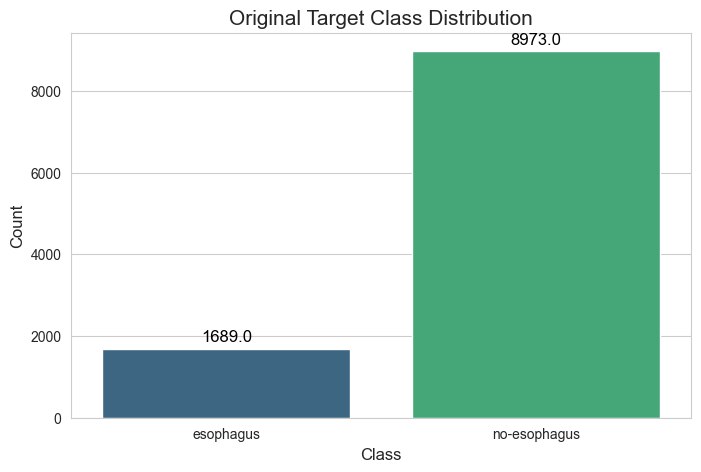

Sample Images from Balanced Training Pipeline:


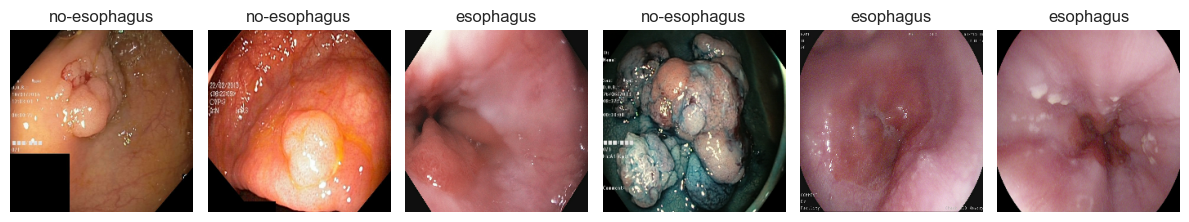

In [4]:
# 1. Class Distribution Plot
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='class_name', data=df, palette='viridis')

plt.title('Original Target Class Distribution', fontsize=15)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

# 2. Visualize Balanced Batch
print("Sample Images from Balanced Training Pipeline:")
plt.figure(figsize=(12, 4))
for images, labels_batch in train_dataset.take(1):
    for i in range(6): # Show top 6
        ax = plt.subplot(1, 6, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

### Cell 05: Model Architecture Definition

Defining the Convolutional Neural Network (CNN) using Transfer Learning:
* **Backbone:** EfficientNetB0 (pretrained on ImageNet, weights frozen).
* **Pooling:** Global Average Pooling to flatten features.
* **Head:** Batch Normalization, Dropout for regularization, and Dense layers.
* **Output Layer:** A single neuron with Sigmoid activation for binary classification.

In [15]:
# Load Base Model
base_model = applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False # Freeze base layers

# --- CHANGED: Use Functional API for SHAP Compatibility ---
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Pass inputs through the base model
x = base_model(inputs, training=False)

# Add the Classification Head
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

# Create the Model
model = models.Model(inputs=inputs, outputs=outputs, name="EfficientNet_Endo_Classifier")

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display Model Architecture
print("Deep Learning Model Summary (Functional API)")
model.summary()

Deep Learning Model Summary (Functional API)


Model: "EfficientNet_Endo_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

### Cell 06: Model Training

Compiling and training the model. We use:
* **EarlyStopping:** To stop training if validation loss stops improving.
* **ReduceLROnPlateau:** To lower the learning rate if the model gets stuck.

In [17]:
# Define Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1),
    TqdmCallback(verbose=1)
]

print("Starting Training...")

# Train the model
history = model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    epochs=20,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=0
)

print("\nTraining Complete.")

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Starting Training...

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 10: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.

Epoch 14: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 11.

Training Complete.


### Cell 07: Performance Visualization

Plotting the Accuracy and Loss curves for both training and validation sets to visually assess convergence and check for overfitting.

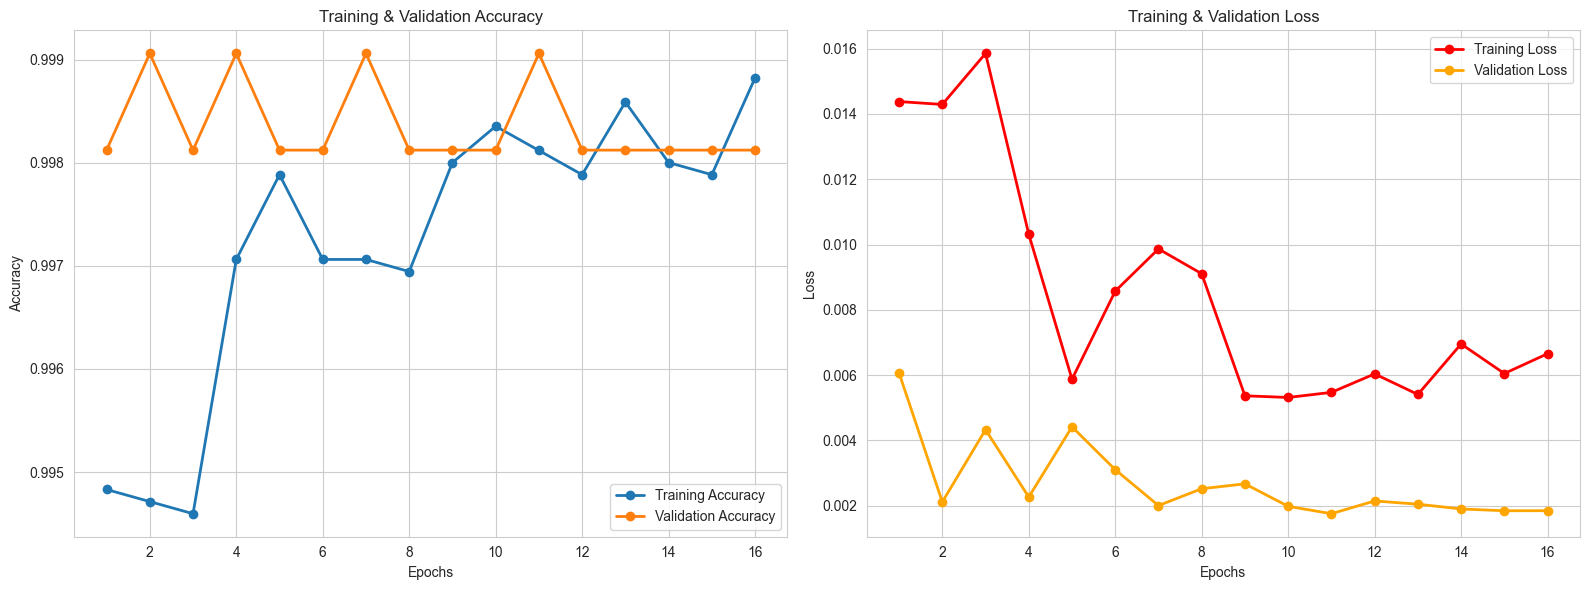

Final Training Accuracy:   0.9988
Final Validation Accuracy: 0.9981


In [18]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Accuracy
ax1.plot(epochs_range, acc, label='Training Accuracy', linewidth=2, marker='o')
ax1.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, marker='o')
ax1.set_title('Training & Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right')
ax1.grid(True)

# Plot Loss
ax2.plot(epochs_range, loss, label='Training Loss', linewidth=2, marker='o', color='red')
ax2.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, marker='o', color='orange')
ax2.set_title('Training & Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right')
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy:   {acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")

### Cell 08: Model Evaluation

Generating predictions on the unseen Test Set and producing a text-based Classification Report for detailed performance metrics.

In [19]:
# 1. Generate Predictions
print("Generating predictions on Test Set...")
y_true = []
y_pred_probs = []

# Iterate over test dataset (unshuffled) to get predictions aligned with labels
for img, label in test_dataset:
    y_true.extend(label.numpy())
    y_pred_probs.extend(model.predict(img, verbose=0))

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

# 2. Metrics
test_acc = accuracy_score(y_true, y_pred)
print(f"Test Set Accuracy: {test_acc*100:.2f}%\n")

print("Classification Report")
print(classification_report(y_true, y_pred, target_names=class_names))

Generating predictions on Test Set...
Test Set Accuracy: 99.72%

Classification Report
              precision    recall  f1-score   support

   esophagus       0.98      1.00      0.99       169
no-esophagus       1.00      1.00      1.00       898

    accuracy                           1.00      1067
   macro avg       0.99      1.00      0.99      1067
weighted avg       1.00      1.00      1.00      1067



### Cell 09: Confusion Matrix

Visualizing the Confusion Matrix as a heatmap to clearly see True Positives, True Negatives, False Positives, and False Negatives.

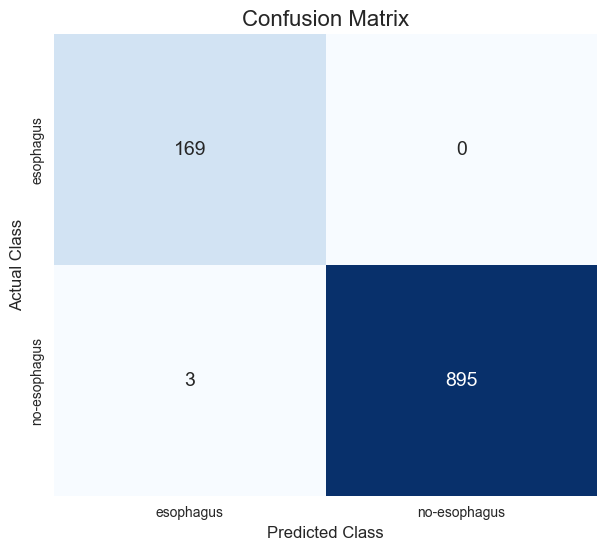

In [20]:
# Generate Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14})

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.show()

### Cell 10: Prediction Analysis

Displaying a visual comparison of sample predictions on the Test Set to qualitatively audit model behavior.

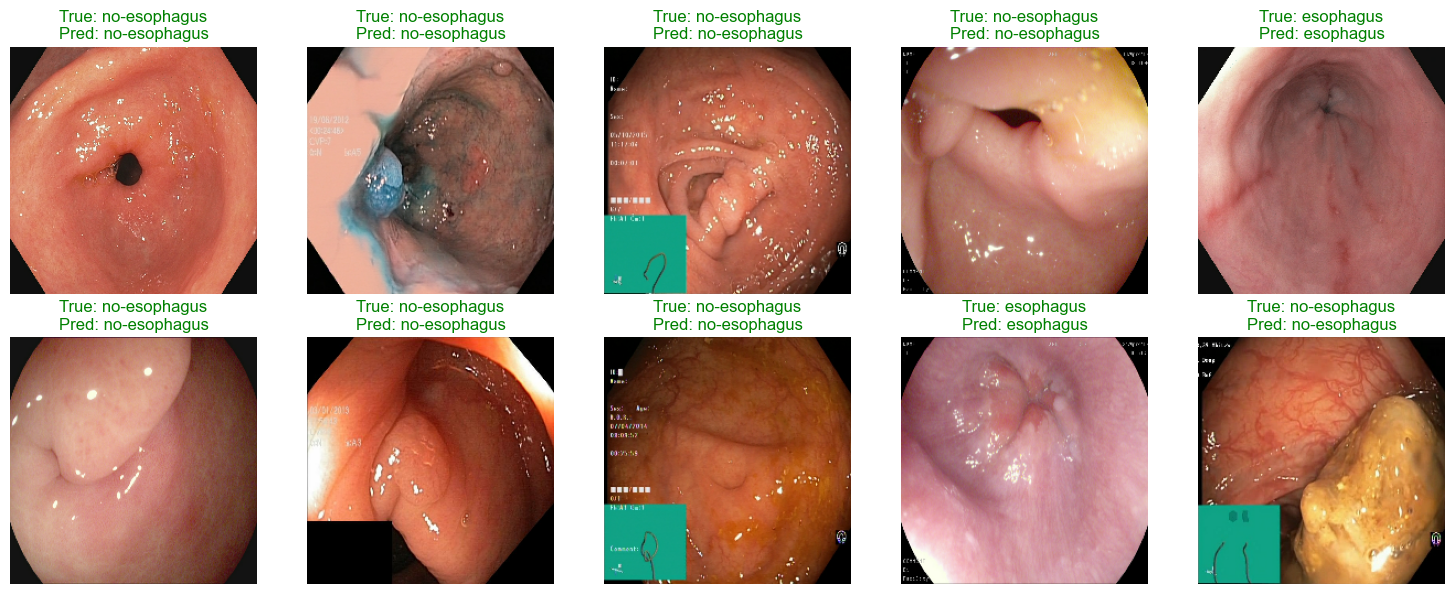

In [21]:
# Visualize some test results
plt.figure(figsize=(15, 6))
for i in range(10): # Check first 10 images from test set
    ax = plt.subplot(2, 5, i + 1)
    # We need to re-fetch images since the pipeline yielded them
    # This is a quick visualization approach using the DataFrame indices
    img_path = test_df.iloc[i]['path']
    actual_label = class_names[test_df.iloc[i]['label']]

    # Predict for single image
    img, _ = load_img(img_path, -1) # Label doesn't matter here
    pred_prob = model.predict(tf.expand_dims(img, axis=0), verbose=0)[0][0]
    pred_label = class_names[int(pred_prob > 0.5)]

    # Color code title: Green if correct, Red if wrong
    color = 'green' if actual_label == pred_label else 'red'

    plt.imshow(img.numpy().astype("uint8"))
    plt.title(f"True: {actual_label}\nPred: {pred_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Cell 11: Save Model & Results

Serializing and saving the trained Model (`.keras`) and classification reports to disk so they can be reused later without retraining.

In [22]:
# 1. Configuration - Using Absolute Paths
MODELS_DIR = r"E:\NLP\Assignment\1&2\Esophageal_Cancer_Project\Models"
REPORTS_DIR = r"E:\NLP\Assignment\1&2\Esophageal_Cancer_Project\Reports"

# Ensure directories exist
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

# Define Model Architecture Name
MODEL_ARCH = "EfficientNetB0"

# Define Filenames
model_filename = f"Imaging_Model_{MODEL_ARCH}.keras"
report_filename = f"Imaging_Report_{MODEL_ARCH}.txt"

# Full Paths
model_save_path = os.path.join(MODELS_DIR, model_filename)
report_save_path = os.path.join(REPORTS_DIR, report_filename)

# 2. Save the Model
print(f"Saving model artifacts to: {MODELS_DIR}...")
model.save(model_save_path)
print("Model saved successfully.")

# 3. Construct Report Content
class_report = classification_report(y_true, y_pred, target_names=class_names)

report_content = f"""Imaging Model Evaluation Report
=========================================
Model Name:      {model_filename}
Architecture:    {MODEL_ARCH}
Input Shape:     {(IMG_SIZE, IMG_SIZE, 3)}
=========================================

Overall Metrics:
----------------
Test Accuracy : {test_acc*100:.2f}%

Classification Report:
----------------------
{class_report}

Confusion Matrix:
-----------------
{cm}
"""

# 4. Save Report to File
print(f"Saving report to: {report_save_path}...")
with open(report_save_path, "w") as f:
    f.write(report_content)

print("Report saved successfully.")
print("\n--- Report Preview ---")
print(report_content)

Saving model artifacts to: E:\NLP\Assignment\1&2\Esophageal_Cancer_Project\Models...
Model saved successfully.
Saving report to: E:\NLP\Assignment\1&2\Esophageal_Cancer_Project\Reports\Imaging_Report_EfficientNetB0.txt...
Report saved successfully.

--- Report Preview ---
Imaging Model Evaluation Report
Model Name:      Imaging_Model_EfficientNetB0.keras
Architecture:    EfficientNetB0
Input Shape:     (224, 224, 3)

Overall Metrics:
----------------
Test Accuracy : 99.72%

Classification Report:
----------------------
              precision    recall  f1-score   support

   esophagus       0.98      1.00      0.99       169
no-esophagus       1.00      1.00      1.00       898

    accuracy                           1.00      1067
   macro avg       0.99      1.00      0.99      1067
weighted avg       1.00      1.00      1.00      1067


Confusion Matrix:
-----------------
[[169   0]
 [  3 895]]



### Code Cell 12: SHAP Interpretation
Using SHAP (SHapley Additive exPlanations) to visualize pixel importance. This identifies which regions of the image are most important *globally* for the model.

Calculating SHAP values (this may take a few moments)...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0036828212905675173..0.007535645272582769].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.004316915757954121..0.00473661907017231].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.004715906456112862..0.0041411216370761395].


SHAP Image Explanation:


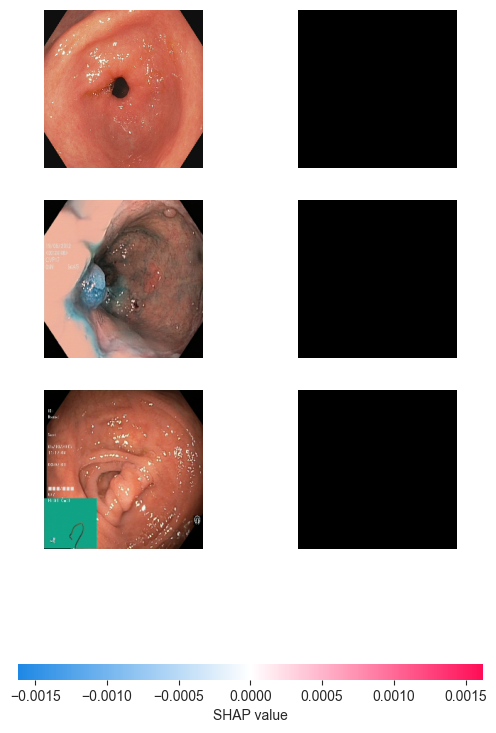

In [23]:
import shap
import numpy as np

# 1. Prepare Background Data
# SHAP needs a background dataset to integrate over. We take a batch from the training set.
background_batch = next(iter(train_dataset))
background_images = background_batch[0].numpy()[:50] # Use 50 images for background

# 2. Prepare Test Images to Explain
test_batch = next(iter(test_dataset))
test_images = test_batch[0].numpy()[:3] # Explain the first 3 images

# 3. Initialize GradientExplainer
# We pass the raw model and raw background (0-255 scale) because that is what the model expects.
explainer = shap.GradientExplainer(model, background_images)

# 4. Calculate SHAP Values
print("Calculating SHAP values (this may take a few moments)...")
shap_values = explainer.shap_values(test_images)

# 5. Plot
# FIX: We divide test_images by 255.0 JUST for plotting so Matplotlib doesn't clip values.
# The shap_values are already calculated correctly on the raw data.
print("SHAP Image Explanation:")
shap.image_plot(shap_values, test_images / 255.0)

### Cell 13: LIME

Using LIME to explain a **single patient's prediction**. This creates a visual explanation showing exactly which superpixels (image regions) pushed the probability towards the predicted class.

Explaining Image #4 (True Class: esophagus)


  0%|          | 0/1000 [00:00<?, ?it/s]

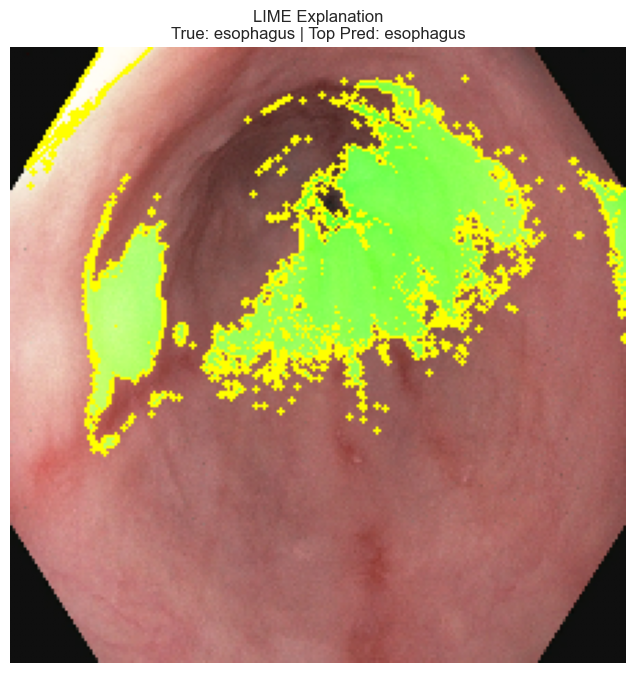

Success! LIME explanation saved as HTML at:
E:\NLP\Assignment\1&2\Esophageal_Cancer_Project\LIME\Imaging_lime_explanation.html


In [24]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import base64
from io import BytesIO
import matplotlib.pyplot as plt

# 1. Define a Wrapper Function for Prediction
# LIME expects predictions in the format [Prob_Class0, Prob_Class1]
def predict_proba_wrapper(images):
    preds = model.predict(images, verbose=0)
    return np.hstack((1 - preds, preds))

# 2. Create the LIME Explainer
explainer_lime = lime_image.LimeImageExplainer()

# 3. Select an Instance to Explain
# Let's pick the 5th image from our test batch
idx_to_explain = 4
img_to_explain = test_batch[0][idx_to_explain].numpy().astype('double')
true_label_idx = int(test_batch[1][idx_to_explain])

print(f"Explaining Image #{idx_to_explain} (True Class: {class_names[true_label_idx]})")

# 4. Generate Explanation
# We use 1000 samples to estimate the local boundary
explanation = explainer_lime.explain_instance(
    img_to_explain,
    predict_proba_wrapper,
    top_labels=2,
    hide_color=0,
    num_samples=1000
)

# 5. Visualize to Memory (for HTML embedding)
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=False,
    num_features=5,
    hide_rest=False
)

# Create the figure
plt.figure(figsize=(8, 8))

# FIX: Normalize 'temp' (which is 0-255) to 0-1 for display
# This prevents the image from looking washed out or gray
plt.imshow(mark_boundaries(temp / 255.0, mask))

plt.title(f"LIME Explanation\nTrue: {class_names[true_label_idx]} | Top Pred: {class_names[explanation.top_labels[0]]}")
plt.axis('off')

# Save plot to a temporary buffer (in memory)
buf = BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight')
buf.seek(0)
# Encode image to Base64 string
img_base64 = base64.b64encode(buf.read()).decode('utf-8')
buf.close()
plt.show()

# 6. Save LIME Artifacts as HTML
LIME_DIR = r"E:\NLP\Assignment\1&2\Esophageal_Cancer_Project\LIME"
os.makedirs(LIME_DIR, exist_ok=True)

html_filename = "Imaging_lime_explanation.html"
html_save_path = os.path.join(LIME_DIR, html_filename)

# Construct HTML content
html_content = f"""
<html>
<head>
    <title>LIME Imaging Explanation</title>
    <style>
        body {{ font-family: Arial, sans-serif; text-align: center; padding: 20px; }}
        .container {{ border: 1px solid #ddd; padding: 20px; display: inline-block; box-shadow: 2px 2px 10px #ccc; }}
        h1 {{ color: #2c3e50; }}
        .info {{ color: #555; margin-bottom: 20px; }}
    </style>
</head>
<body>
    <div class="container">
        <h1>LIME Interpretation Result</h1>
        <div class="info">
            <p><b>Image Index:</b> {idx_to_explain}</p>
            <p><b>Actual Label:</b> {class_names[true_label_idx]}</p>
            <p><b>Predicted Label:</b> {class_names[explanation.top_labels[0]]}</p>
        </div>
        <img src="data:image/png;base64,{img_base64}" alt="LIME Explanation" />
        <p><i>Green regions indicate support for the predicted class. Red regions indicate opposition.</i></p>
    </div>
</body>
</html>
"""

# Write to file
with open(html_save_path, "w", encoding='utf-8') as f:
    f.write(html_content)

print(f"Success! LIME explanation saved as HTML at:\n{html_save_path}")